# Cx47 and Mitochondrial Recovery Across LPC DBiT Timepoints

This notebook explores whether Cx47 (`GJC2` / `Gjc2`) loss and re-expression tracks mitochondrial recovery across LPC day 5, day 10, and day 21 DBiT RNA datasets.

Because these are DBiT spatial spots rather than single cells, the oligodendroglial analysis below should be interpreted as **oligodendrocyte-enriched spots**. The notebook first scores lineage and mitochondrial panels, then infers putative oligodendroglial clusters within each day before testing timepoint trajectories and stage-specific correlations.

The three files are all `S1`, so any peak-stage call here is exploratory and should be treated as a within-series trend rather than replicate-level statistical proof.


In [1]:
from pathlib import Path
import os
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from IPython.display import Markdown, display

CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
REPO_ROOT = next((path for path in CANDIDATES if (path / "src").exists() and (path / "config").exists()), None)
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repository root. Start Jupyter from the repo root or notebooks directory.")

MPL_CACHE_DIR = REPO_ROOT / ".cache" / "matplotlib"
MPL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR))

if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from cx47_oligo.gene_panels import GENE_PANELS
from cx47_oligo.exports import ensure_results_dir, save_current_figure, save_json, save_table
from cx47_oligo.h5ad_tools import (
    adata_overview,
    expression_frame,
    obs_column_summary,
    panel_availability_table,
    resolve_gene_symbols,
    score_gene_panel,
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#fbfcfd",
        "axes.edgecolor": "#d7dde2",
        "grid.color": "#dde4ea",
        "grid.alpha": 0.75,
    }
)


In [2]:
DATASET_PATHS = {
    5: Path("/Volumes/processing2/KaroSpaceDataWrangle/dbit-data/DBiT_Di/LPC5_S1_RNA.h5ad"),
    10: Path("/Volumes/processing2/KaroSpaceDataWrangle/dbit-data/DBiT_Di/LPC10_S1_RNA.h5ad"),
    21: Path("/Volumes/processing2/KaroSpaceDataWrangle/dbit-data/DBiT_Di/LPC21_S1_RNA.h5ad"),
}

for day, path in DATASET_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing LPC dataset for day {day}: {path}")

RESULTS_DIR = ensure_results_dir(REPO_ROOT, "02_cx47_mitochondrial_recovery_lpc", "lpc_multi_timepoints")
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TARGET_GENES = ["GJC2", "GJB1", "GJA1"]
LINEAGE_PANELS = ["oligodendrocyte_identity", "astrocyte_identity", "microglial_activation"]
MITO_PANELS = [
    "mitochondrial_oxphos",
    "mitochondrial_biogenesis",
    "mitochondrial_membrane_transport",
    "mitochondrial_dynamics",
    "metabolic_coupling",
]
ALL_PANELS = ["panglial_connexins", *LINEAGE_PANELS, *MITO_PANELS]

TIME_ORDER = [f"Day {day}" for day in sorted(DATASET_PATHS)]

print("Results:", RESULTS_DIR)
for day, path in sorted(DATASET_PATHS.items()):
    print(f"Day {day}: {path}")


Results: /Users/chrislangseth/work/karolinska_institutet/projects/cx47-oligo/results/02_cx47_mitochondrial_recovery_lpc/lpc_multi_timepoints
Day 5: /Volumes/processing2/KaroSpaceDataWrangle/dbit-data/DBiT_Di/LPC5_S1_RNA.h5ad
Day 10: /Volumes/processing2/KaroSpaceDataWrangle/dbit-data/DBiT_Di/LPC10_S1_RNA.h5ad
Day 21: /Volumes/processing2/KaroSpaceDataWrangle/dbit-data/DBiT_Di/LPC21_S1_RNA.h5ad


In [3]:
adatas = []
dataset_rows = []

for day, path in sorted(DATASET_PATHS.items()):
    adata_day = ad.read_h5ad(path)
    adata_day.obs_names_make_unique()
    adata_day.var_names_make_unique()
    adata_day.obs = adata_day.obs.copy()
    adata_day.obs["day_post_lpc"] = day
    adata_day.obs["timepoint_label"] = f"Day {day}"
    adata_day.obs["source_file"] = path.name
    adata_day.obs["sample_id"] = path.stem.replace("_RNA", "")
    adata_day.obs["cluster_day"] = adata_day.obs["timepoint_label"].astype(str) + " | " + adata_day.obs["clusters"].astype(str)
    adata_day.uns.setdefault("source_dataset", {})
    adata_day.uns["source_dataset"]["value_type"] = "normalized"
    adatas.append(adata_day)
    dataset_rows.append(
        {
            "day_post_lpc": day,
            "timepoint_label": f"Day {day}",
            "source_file": path.name,
            "n_spots": adata_day.n_obs,
            "n_genes": adata_day.n_vars,
        }
    )

adata = ad.concat(adatas, join="inner", merge="same", index_unique="__")
adata.uns.setdefault("source_dataset", {})
adata.uns["source_dataset"]["value_type"] = "normalized"

# Free per-day matrices now that concat is done
del adatas
import gc

# Subset to only the genes needed for scoring and plotting (~150 genes vs 23k).
# This is the main memory fix — keeps the expression matrix small for all downstream steps.
_query_genes = list(dict.fromkeys(
    [g for panel in ALL_PANELS for g in GENE_PANELS[panel]] + list(TARGET_GENES)
))
_, _, _gene_to_var = resolve_gene_symbols(adata, _query_genes)
_keep_vars = list(dict.fromkeys(_gene_to_var.values()))
print(f"Gene subset: {adata.n_vars:,} → {len(_keep_vars)} vars kept")
adata = adata[:, _keep_vars].copy()
gc.collect()


display(adata_overview(adata))

dataset_summary = pd.DataFrame(dataset_rows).sort_values("day_post_lpc")
display(dataset_summary)

metadata_columns = [column for column in ["day_post_lpc", "timepoint_label", "sample_id", "source_file", "clusters", "x", "y", "nCount_RNA", "nFeature_RNA"] if column in adata.obs.columns]
metadata_summary = obs_column_summary(adata).loc[lambda df: df["column"].isin(metadata_columns)]
display(metadata_summary)

panel_coverage = panel_availability_table(adata, ALL_PANELS)
display(panel_coverage)

present_genes, missing_genes, gene_to_var = resolve_gene_symbols(adata, TARGET_GENES)
gene_status = pd.DataFrame(
    {
        "query_gene": TARGET_GENES,
        "resolved_var": [gene_to_var.get(gene, "") for gene in TARGET_GENES],
        "present_in_dataset": [gene in present_genes for gene in TARGET_GENES],
    }
)
display(gene_status)

save_table(dataset_summary, RESULTS_DIR / "dataset_summary.csv", index=False)
save_table(metadata_summary, RESULTS_DIR / "core_obs_summary.csv", index=False)
save_table(panel_coverage, RESULTS_DIR / "panel_coverage.csv", index=False)
save_table(gene_status, RESULTS_DIR / "target_gene_status.csv", index=False)

save_json(
    {
        "dataset_paths": {str(day): str(path) for day, path in DATASET_PATHS.items()},
        "results_dir": str(RESULTS_DIR),
        "time_order": TIME_ORDER,
        "target_genes": TARGET_GENES,
        "lineage_panels": LINEAGE_PANELS,
        "mitochondrial_panels": MITO_PANELS,
    },
    RESULTS_DIR / "run_metadata.json",
)

if missing_genes:
    display(Markdown("**Missing genes:** " + ", ".join(f"`{gene}`" for gene in missing_genes)))


Gene subset: 23,364 → 60 vars kept


,metric,value
0,n_obs,25401
1,n_vars,60
2,obs_columns,12
3,var_columns,0
4,layers,(none)
5,obsm,(none)
6,uns_keys,source_dataset
7,raw_present,True


,day_post_lpc,timepoint_label,source_file,n_spots,n_genes
0,5,Day 5,LPC5_S1_RNA.h5ad,8736,23364
1,10,Day 10,LPC10_S1_RNA.h5ad,8180,23364
2,21,Day 21,LPC21_S1_RNA.h5ad,8485,23364


,column,dtype,n_unique,null_fraction,examples
1,day_post_lpc,int64,3,0.0,"5, 10, 21"
2,sample_id,object,3,0.0,"LPC5_S1, LPC10_S1, LPC21_S1"
3,source_file,object,3,0.0,"LPC5_S1_RNA.h5ad, LPC10_S1_RNA.h5ad, LPC21_S1_..."
4,timepoint_label,object,3,0.0,"Day 5, Day 10, Day 21"
5,clusters,object,15,0.0,"C1, C2, C3, C4"
8,x,float64,283,0.0,"504.0, 67.0, 515.0, 45.0"
9,y,float64,283,0.0,"32.0, 74.0, 42.0, 21.0"
10,nFeature_RNA,int32,4181,0.0,"20387, 20354, 20355, 20545"
11,nCount_RNA,float64,25401,0.0,"7623.697088919765, 7563.908323821433, 7568.782..."


,panel,panel_size,present_count,missing_count,coverage,present_genes,missing_genes
0,astrocyte_identity,5,5,0,1.000,"GFAP, AQP4, ALDH1L1, SLC1A2, SLC1A3",
1,metabolic_coupling,4,4,0,1.000,"SLC16A1, SLC16A3, LDHA, LDHB",
2,mitochondrial_biogenesis,4,4,0,1.000,"PPARGC1A, TFAM, NRF1, NFE2L2",
3,mitochondrial_dynamics,5,5,0,1.000,"MFN1, MFN2, OPA1, DNM1L, FIS1",
4,oligodendrocyte_identity,10,10,0,1.000,"MBP, MOG, PLP1, MAG, CNP, SOX10, OLIG2, NKX2-2...",
5,panglial_connexins,6,6,0,1.000,"GJC2, GJB1, GJC3, GJA1, GJB6, GJD2",
6,mitochondrial_membrane_transport,11,10,1,0.909,"VDAC1, VDAC2, VDAC3, TOMM20, TOMM40, SLC25A4, ...",TOMM70
7,microglial_activation,7,6,1,0.857,"NOS2, CD68, ITGAM, AIF1, C1QA, C3",HLA-DRA
8,mitochondrial_oxphos,14,11,3,0.786,"NDUFA9, NDUFS1, NDUFS3, NDUFB8, SDHA, SDHB, UQ...","ATP5F1A, ATP5F1B, ATP5MC1"


,query_gene,resolved_var,present_in_dataset
0,GJC2,Gjc2,True
1,GJB1,Gjb1,True
2,GJA1,Gja1,True


In [4]:
def reorder_matrix(frame, row_order=None, col_order=None):
    working = frame.copy()
    if row_order is not None:
        rows = [row for row in row_order if row in working.index]
        extra_rows = [row for row in working.index if row not in rows]
        working = working.reindex(rows + extra_rows)
    if col_order is not None:
        cols = [col for col in col_order if col in working.columns]
        extra_cols = [col for col in working.columns if col not in cols]
        working = working.reindex(columns=cols + extra_cols)
    return working


def plot_heatmap(frame, title, cmap="mako", center=None, rotation=35):
    fig, ax = plt.subplots(figsize=(max(6, 1.05 * len(frame.columns) + 2), max(4.5, 0.45 * len(frame.index) + 2.2)))
    sns.heatmap(frame, cmap=cmap, center=center, linewidths=0.4, linecolor="white", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.xticks(rotation=rotation, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()


def two_way_expression_stats(adata_input, genes, row_col, col_col):
    expr = expression_frame(adata_input, genes)
    if expr.empty:
        empty = pd.DataFrame()
        return {"n_cells": empty, "mean_expression": empty, "pct_expressing": empty}

    frame = adata_input.obs[[row_col, col_col]].copy().join(expr).dropna(subset=[row_col, col_col])
    frame[row_col] = frame[row_col].astype(str)
    frame[col_col] = frame[col_col].astype(str)
    gene_columns = list(expr.columns)
    group_cols = [row_col, col_col]

    counts = frame.groupby(group_cols, observed=True).size().rename("n_spots").to_frame()
    mean_expression = frame.groupby(group_cols, observed=True)[gene_columns].mean()

    detected = frame[gene_columns].gt(0).astype(float)
    detected[row_col] = frame[row_col].values
    detected[col_col] = frame[col_col].values
    pct_expressing = detected.groupby(group_cols, observed=True)[gene_columns].mean().mul(100.0)

    return {"n_cells": counts, "mean_expression": mean_expression, "pct_expressing": pct_expressing}


def plot_feature_timecourse(frame, x_col, feature_cols, x_order, title):
    plot_df = frame.copy()
    plot_df[x_col] = pd.Categorical(plot_df[x_col], categories=x_order, ordered=True)
    long_df = plot_df.melt(id_vars=x_col, value_vars=feature_cols, var_name="feature", value_name="value")
    fig, ax = plt.subplots(figsize=(max(7, 1.4 * len(x_order) + 3), 5.2))
    sns.lineplot(data=long_df, x=x_col, y="value", hue="feature", marker="o", sort=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Value")
    ax.legend(title="Feature", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.xticks(rotation=0)
    plt.tight_layout()
    return long_df


def spearman_by_group(frame, group_col, x, y, min_n=20):
    rows = []
    for group, sub in frame.groupby(group_col, observed=True):
        valid = sub[[x, y]].dropna()
        if len(valid) < min_n or valid[x].nunique() < 2 or valid[y].nunique() < 2:
            rows.append({"group": group, "n": len(valid), "rho": np.nan, "pvalue": np.nan})
            continue
        rho, pvalue = spearmanr(valid[x], valid[y])
        rows.append({"group": group, "n": len(valid), "rho": rho, "pvalue": pvalue})
    return pd.DataFrame(rows)


def plot_scatter_by_day(frame, x, y, day_col, day_order, title_prefix):
    fig, axes = plt.subplots(1, len(day_order), figsize=(max(12, 4.4 * len(day_order)), 4.5), sharex=False, sharey=False)
    if len(day_order) == 1:
        axes = [axes]
    for ax, day in zip(axes, day_order):
        sub = frame.loc[frame[day_col] == day]
        sns.scatterplot(data=sub, x=x, y=y, ax=ax, s=18, alpha=0.28, linewidth=0)
        ax.set_title(day)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
    fig.suptitle(title_prefix, y=1.03)
    plt.tight_layout()


def plot_correlation_trajectory(corr_df, day_order, title):
    if corr_df.empty:
        return corr_df
    plot_df = corr_df.copy()
    plot_df["group"] = pd.Categorical(plot_df["group"], categories=day_order, ordered=True)
    fig, ax = plt.subplots(figsize=(max(7, 1.4 * len(day_order) + 3), 5))
    sns.lineplot(data=plot_df, x="group", y="rho", hue="score", marker="o", sort=False, ax=ax)
    ax.axhline(0, color="#666666", linewidth=1, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Spearman rho")
    ax.legend(title="Score", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.xticks(rotation=0)
    plt.tight_layout()
    return plot_df


## Lineage and Mitochondrial Scoring

Because there are no manual cell-type labels in these DBiT exports, the notebook first scores lineage panels and summarizes each `day | cluster` combination before selecting putative oligodendroglial clusters.


,panel,score_column,genes_used,genes_missing,missing_genes,normalization
0,panglial_connexins,panglial_connexins_score,6,0,,as_is
1,oligodendrocyte_identity,oligodendrocyte_identity_score,10,0,,as_is
2,astrocyte_identity,astrocyte_identity_score,5,0,,as_is
3,microglial_activation,microglial_activation_score,6,1,HLA-DRA,as_is
4,mitochondrial_oxphos,mitochondrial_oxphos_score,11,3,"ATP5F1A, ATP5F1B, ATP5MC1",as_is
5,mitochondrial_biogenesis,mitochondrial_biogenesis_score,4,0,,as_is
6,mitochondrial_membrane_transport,mitochondrial_membrane_transport_score,10,1,TOMM70,as_is
7,mitochondrial_dynamics,mitochondrial_dynamics_score,5,0,,as_is
8,metabolic_coupling,metabolic_coupling_score,4,0,,as_is


,day_post_lpc,clusters,dominant_lineage,auto_oligo,GJC2_expr,GJB1_expr,GJA1_expr,oligodendrocyte_identity_score,astrocyte_identity_score,microglial_activation_score,mitochondrial_oxphos_score,mitochondrial_biogenesis_score,mitochondrial_recovery_score
cluster_day,,,,,,,,,,,,,
Day 5 | C1,5,C1,oligodendrocyte_identity_score,True,0.251,0.145,0.542,0.104,0.021,-0.199,-0.257,0.216,-0.032
Day 5 | C10,5,C10,astrocyte_identity_score,False,0.055,0.057,0.321,-0.868,-0.369,-0.408,-0.893,-0.081,-0.869
Day 5 | C11,5,C11,microglial_activation_score,False,0.144,0.056,0.409,-0.586,-0.648,-0.362,-0.774,-0.269,-0.666
Day 5 | C12,5,C12,oligodendrocyte_identity_score,False,0.144,0.120,0.412,-0.279,-0.515,-0.385,-0.599,-0.096,-0.498
Day 5 | C13,5,C13,microglial_activation_score,False,0.171,0.061,0.420,-0.288,-0.490,-0.233,-0.434,-0.143,-0.302
Day 5 | C14,5,C14,astrocyte_identity_score,False,0.197,0.111,0.511,-0.126,0.063,-0.277,-0.386,-0.204,-0.299
Day 5 | C15,5,C15,astrocyte_identity_score,False,0.104,0.082,0.457,-0.460,0.012,-0.281,-0.609,0.045,-0.521
Day 5 | C2,5,C2,astrocyte_identity_score,False,0.222,0.120,0.539,-0.060,0.528,0.452,-0.295,0.076,-0.144
Day 5 | C3,5,C3,astrocyte_identity_score,False,0.083,0.070,0.354,-0.622,-0.238,-0.331,-0.636,0.049,-0.554


**Auto-selected oligodendroglial clusters:** `Day 5 | C1`, `Day 5 | C9`, `Day 10 | C1`, `Day 10 | C12`, `Day 10 | C13`, `Day 10 | C14`, `Day 10 | C15`, `Day 10 | C4`, `Day 10 | C8`, `Day 10 | C9`, `Day 21 | C1`, `Day 21 | C9`

**Active oligodendroglial clusters for downstream analysis:** `Day 5 | C1`, `Day 5 | C9`, `Day 10 | C1`, `Day 10 | C12`, `Day 10 | C13`, `Day 10 | C14`, `Day 10 | C15`, `Day 10 | C4`, `Day 10 | C8`, `Day 10 | C9`, `Day 21 | C1`, `Day 21 | C9`

PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/cx47-oligo/results/02_cx47_mitochondrial_recovery_lpc/lpc_multi_timepoints/oligo_cluster_selection.json')

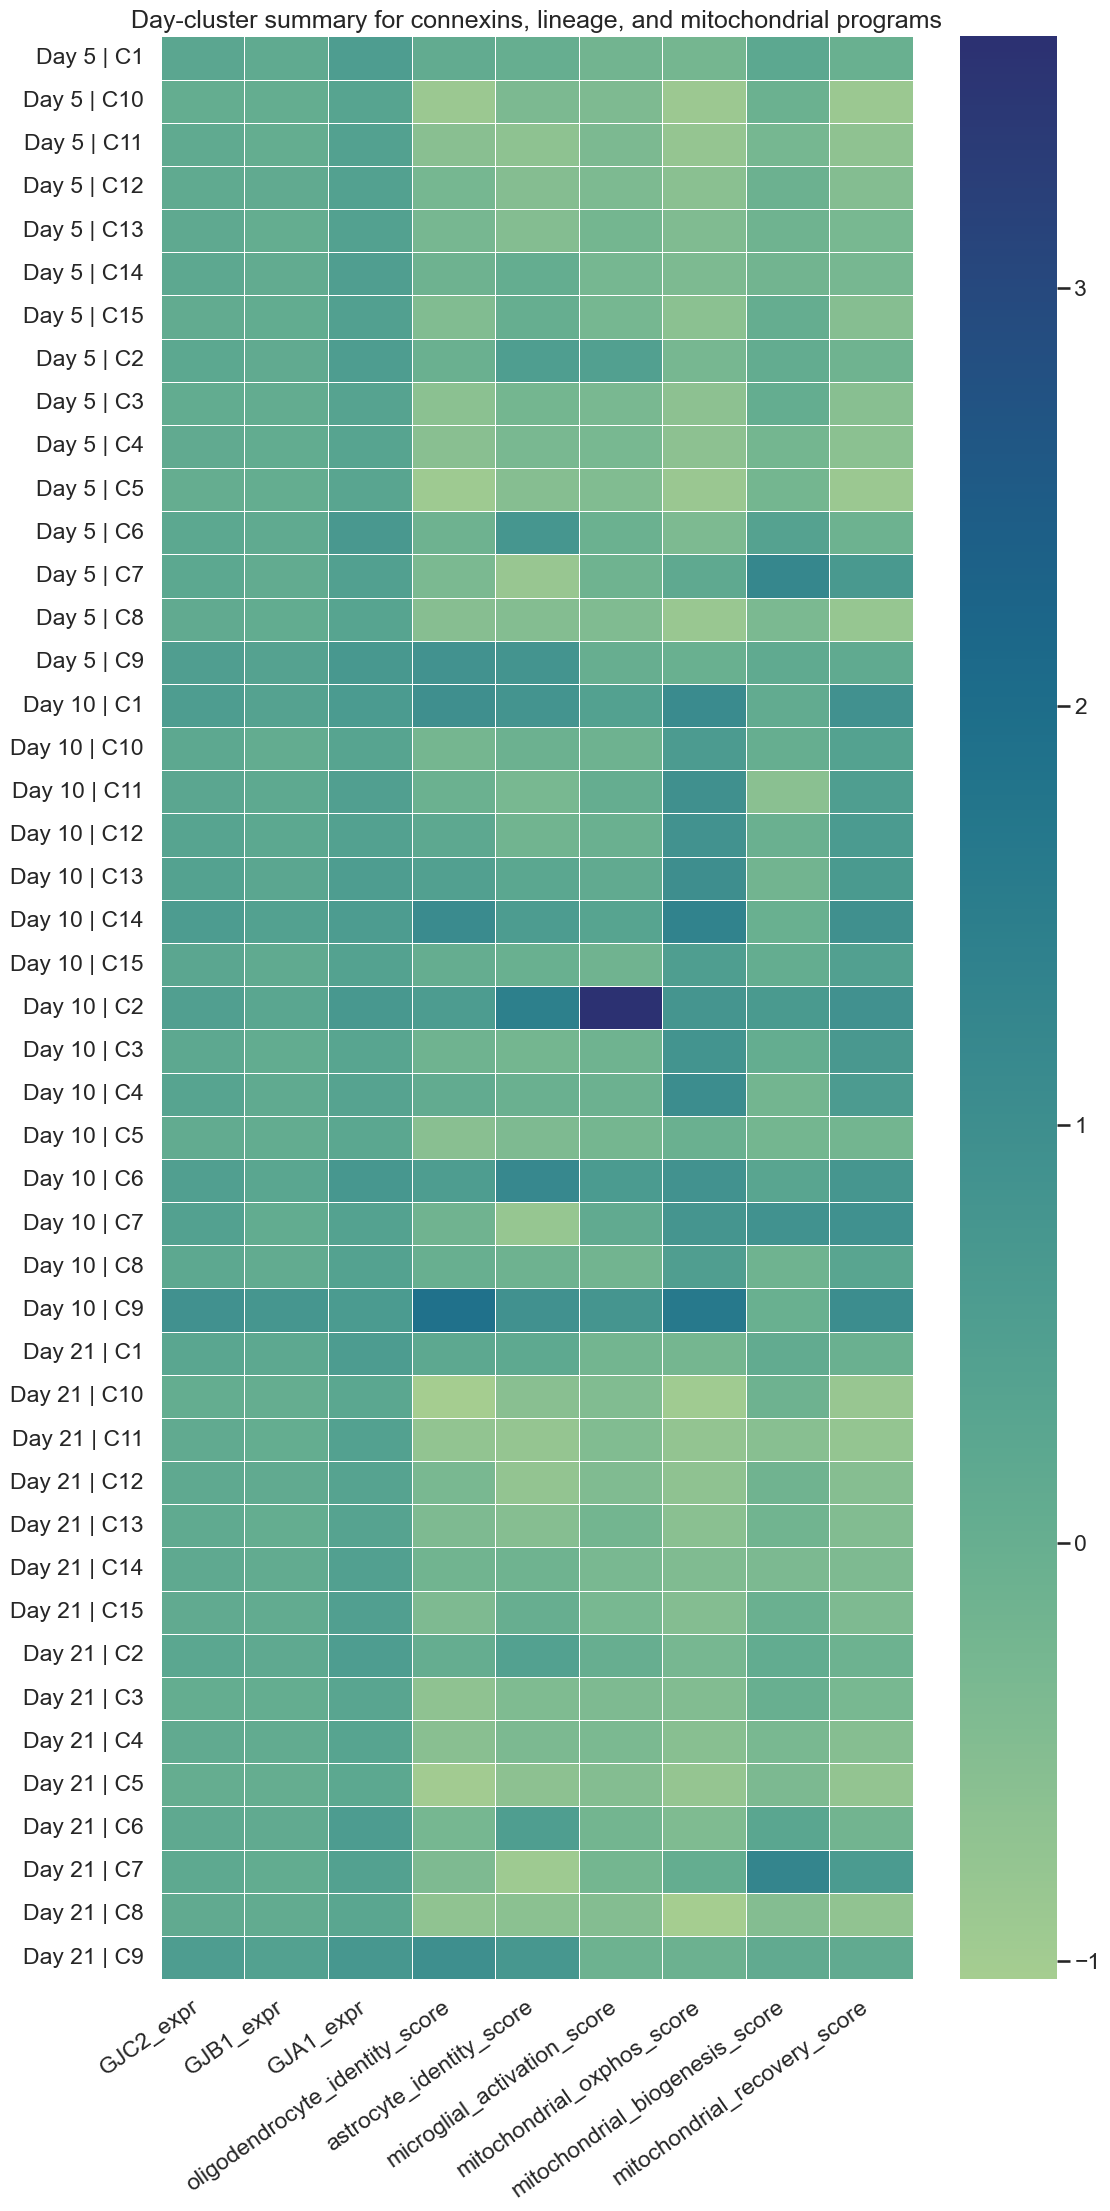

In [5]:
panel_rows = []
score_columns = []

for panel_name in ALL_PANELS:
    try:
        score, metadata = score_gene_panel(adata, panel_name, normalize_counts=False)
        adata.obs[score.name] = score
        panel_rows.append(metadata)
        score_columns.append(score.name)
    except ValueError:
        panel_rows.append(
            {
                "panel": panel_name,
                "score_column": "(not scored)",
                "genes_used": 0,
                "genes_missing": len(GENE_PANELS[panel_name]),
                "missing_genes": ", ".join(GENE_PANELS[panel_name]),
                "normalization": "as_is",
            }
        )

panel_summary = pd.DataFrame(panel_rows)
display(panel_summary)
save_table(panel_summary, RESULTS_DIR / "panel_score_summary.csv", index=False)

connexin_expr = expression_frame(adata, TARGET_GENES, normalize_counts=False)
for gene in connexin_expr.columns:
    adata.obs[f"{gene}_expr"] = connexin_expr[gene].values

mito_component_cols = [f"{panel}_score" for panel in MITO_PANELS if f"{panel}_score" in adata.obs.columns]
if mito_component_cols:
    scaled_components = adata.obs[mito_component_cols].apply(
        lambda s: (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) else 1.0)
    )
    adata.obs["mitochondrial_recovery_score"] = scaled_components.mean(axis=1)

cluster_feature_cols = [
    column
    for column in [
        "GJC2_expr",
        "GJB1_expr",
        "GJA1_expr",
        "oligodendrocyte_identity_score",
        "astrocyte_identity_score",
        "microglial_activation_score",
        "mitochondrial_oxphos_score",
        "mitochondrial_biogenesis_score",
        "mitochondrial_recovery_score",
    ]
    if column in adata.obs.columns
]

cluster_meta = adata.obs[["cluster_day", "day_post_lpc", "timepoint_label", "clusters"]].drop_duplicates().set_index("cluster_day")
cluster_summary = cluster_meta.join(adata.obs.groupby("cluster_day", observed=True)[cluster_feature_cols].mean())

lineage_cols = [column for column in ["oligodendrocyte_identity_score", "astrocyte_identity_score", "microglial_activation_score"] if column in cluster_summary.columns]
if lineage_cols:
    cluster_summary["dominant_lineage"] = cluster_summary[lineage_cols].idxmax(axis=1)
    oligo_cutoff = cluster_summary["oligodendrocyte_identity_score"].median() if "oligodendrocyte_identity_score" in cluster_summary.columns else 0
    cluster_summary["auto_oligo"] = (
        cluster_summary["dominant_lineage"].eq("oligodendrocyte_identity_score")
        & cluster_summary["oligodendrocyte_identity_score"].ge(oligo_cutoff)
    )
else:
    cluster_summary["dominant_lineage"] = "(unavailable)"
    cluster_summary["auto_oligo"] = False

cluster_summary = cluster_summary.sort_values(["day_post_lpc", "clusters"])
AUTO_OLIGO_CLUSTERS = cluster_summary.index[cluster_summary["auto_oligo"]].tolist()
MANUAL_OLIGO_CLUSTERS = []
SELECTED_OLIGO_CLUSTERS = MANUAL_OLIGO_CLUSTERS or AUTO_OLIGO_CLUSTERS

display(cluster_summary[[column for column in ["day_post_lpc", "clusters", "dominant_lineage", "auto_oligo", *cluster_feature_cols] if column in cluster_summary.columns]].round(3))
save_table(cluster_summary, RESULTS_DIR / "cluster_day_summary.csv")

heatmap_order = cluster_summary.index.tolist()
heatmap_cols = [column for column in ["GJC2_expr", "GJB1_expr", "GJA1_expr", *lineage_cols, "mitochondrial_oxphos_score", "mitochondrial_biogenesis_score", "mitochondrial_recovery_score"] if column in cluster_summary.columns]
plot_heatmap(cluster_summary.loc[heatmap_order, heatmap_cols], "Day-cluster summary for connexins, lineage, and mitochondrial programs", cmap="crest")
#save_current_figure(FIGURES_DIR / "cluster_day_summary_heatmap.png")

display(Markdown("**Auto-selected oligodendroglial clusters:** " + (", ".join(f"`{label}`" for label in AUTO_OLIGO_CLUSTERS) if AUTO_OLIGO_CLUSTERS else "none")))
display(Markdown("**Active oligodendroglial clusters for downstream analysis:** " + (", ".join(f"`{label}`" for label in SELECTED_OLIGO_CLUSTERS) if SELECTED_OLIGO_CLUSTERS else "none")))

save_json(
    {
        "auto_oligo_clusters": AUTO_OLIGO_CLUSTERS,
        "manual_oligo_clusters": MANUAL_OLIGO_CLUSTERS,
        "selected_oligo_clusters": SELECTED_OLIGO_CLUSTERS,
    },
    RESULTS_DIR / "oligo_cluster_selection.json",
)


## Oligodendroglial Spot Trajectories Across LPC Time

This section restricts to the selected oligodendrocyte-enriched spots and asks whether Cx47 and mitochondrial programs show a day 5 to day 21 recovery trend.


,n_spots
timepoint_label,
Day 5,1955
Day 10,3997
Day 21,1522


,GJC2_expr,GJB1_expr,mitochondrial_oxphos_score,mitochondrial_biogenesis_score,mitochondrial_recovery_score,metabolic_coupling_score,GJC2_pct_positive
timepoint_label,,,,,,,
Day 5,0.360,0.243,-0.165,0.183,0.042,-0.168,100.0
Day 10,0.635,0.490,1.323,-0.082,0.845,0.824,100.0
Day 21,0.462,0.358,-0.150,0.119,0.066,-0.084,100.0


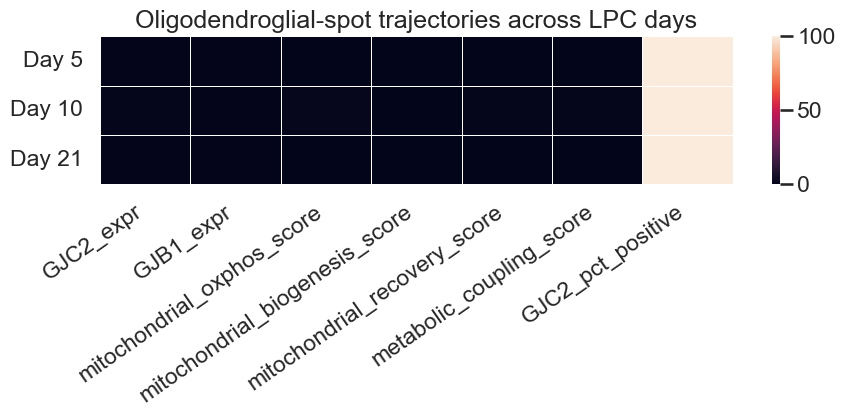

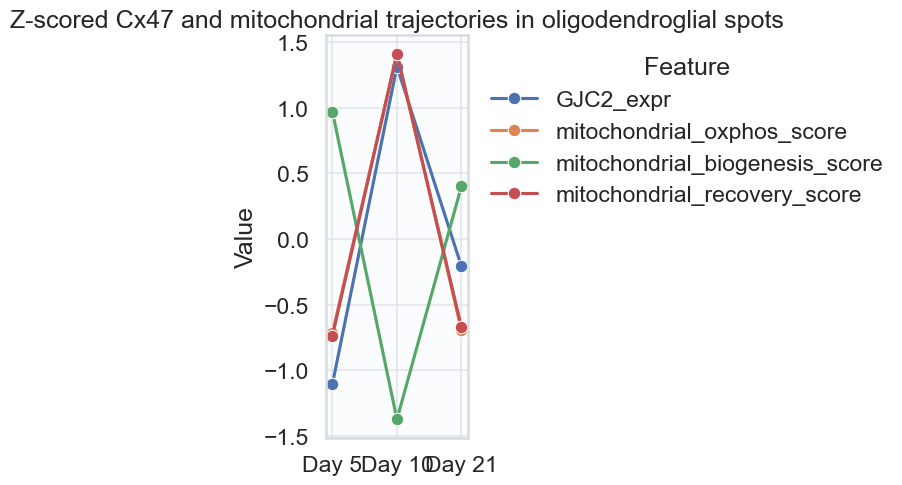

In [6]:
if not SELECTED_OLIGO_CLUSTERS:
    print("No oligodendroglial clusters are selected. Edit MANUAL_OLIGO_CLUSTERS if needed.")
else:
    adata_oligo = adata[adata.obs["cluster_day"].isin(SELECTED_OLIGO_CLUSTERS)].copy()
    oligo_counts = adata_oligo.obs["timepoint_label"].value_counts().reindex(TIME_ORDER).fillna(0).astype(int).to_frame("n_spots")
    display(oligo_counts)
    save_table(oligo_counts, RESULTS_DIR / "oligo_spot_counts_by_day.csv")

    trajectory_cols = [column for column in ["GJC2_expr", "GJB1_expr", "mitochondrial_oxphos_score", "mitochondrial_biogenesis_score", "mitochondrial_recovery_score", "metabolic_coupling_score"] if column in adata_oligo.obs.columns]
    oligo_day_means = adata_oligo.obs.groupby("timepoint_label", observed=True)[trajectory_cols].mean().reindex(TIME_ORDER)
    if "GJC2_expr" in adata_oligo.obs.columns:
        gjc2_pct = (
            adata_oligo.obs.assign(GJC2_positive=adata_oligo.obs["GJC2_expr"] > 0)
            .groupby("timepoint_label", observed=True)["GJC2_positive"]
            .mean()
            .mul(100.0)
            .reindex(TIME_ORDER)
        )
        oligo_day_means["GJC2_pct_positive"] = gjc2_pct

    display(oligo_day_means.round(3))
    save_table(oligo_day_means, RESULTS_DIR / "oligo_day_means.csv")

    plot_heatmap(oligo_day_means, "Oligodendroglial-spot trajectories across LPC days", cmap="rocket")
    #save_current_figure(FIGURES_DIR / "oligo_day_means_heatmap.png")

    timecourse_cols = [column for column in ["GJC2_expr", "mitochondrial_oxphos_score", "mitochondrial_biogenesis_score", "mitochondrial_recovery_score"] if column in oligo_day_means.columns]
    scaled_timecourse = oligo_day_means[timecourse_cols].apply(
        lambda s: (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) else 1.0)
    )
    plot_feature_timecourse(scaled_timecourse.reset_index(), "timepoint_label", list(scaled_timecourse.columns), TIME_ORDER, "Z-scored Cx47 and mitochondrial trajectories in oligodendroglial spots")
    #save_current_figure(FIGURES_DIR / "oligo_day_timecourse_zscored.png")


## Correlation and Peak-Stage Analysis

To go beyond co-trending, this section quantifies how tightly `GJC2` tracks mitochondrial programs within the selected oligodendroglial spots. Because there is only one section per day, the notebook reports both spot-level correlations and a more conservative **cluster-pseudobulk** correlation within each day.


,group,n,rho,pvalue,score,level
0,Day 10,3997,0.638,0.000,mitochondrial_oxphos_score,spot
1,Day 21,1522,0.346,0.000,mitochondrial_oxphos_score,spot
2,Day 5,1955,0.536,0.000,mitochondrial_oxphos_score,spot
3,Day 10,3997,0.134,0.000,mitochondrial_biogenesis_score,spot
4,Day 21,1522,-0.027,0.295,mitochondrial_biogenesis_score,spot
5,Day 5,1955,-0.152,0.000,mitochondrial_biogenesis_score,spot
6,Day 10,3997,0.442,0.000,mitochondrial_recovery_score,spot
7,Day 21,1522,0.266,0.000,mitochondrial_recovery_score,spot
8,Day 5,1955,0.387,0.000,mitochondrial_recovery_score,spot
9,Day 10,3997,0.599,0.000,metabolic_coupling_score,spot


,group,n,rho,pvalue,score,level
0,Day 10,8,0.929,0.001,mitochondrial_oxphos_score,cluster_pseudobulk
1,Day 21,2,NaN,NaN,mitochondrial_oxphos_score,cluster_pseudobulk
2,Day 5,2,NaN,NaN,mitochondrial_oxphos_score,cluster_pseudobulk
3,Day 10,8,0.333,0.420,mitochondrial_biogenesis_score,cluster_pseudobulk
4,Day 21,2,NaN,NaN,mitochondrial_biogenesis_score,cluster_pseudobulk
5,Day 5,2,NaN,NaN,mitochondrial_biogenesis_score,cluster_pseudobulk
6,Day 10,8,1.000,0.000,mitochondrial_recovery_score,cluster_pseudobulk
7,Day 21,2,NaN,NaN,mitochondrial_recovery_score,cluster_pseudobulk
8,Day 5,2,NaN,NaN,mitochondrial_recovery_score,cluster_pseudobulk
9,Day 10,8,0.905,0.002,metabolic_coupling_score,cluster_pseudobulk


,group,n,rho,pvalue,score,level
0,Day 10,8,0.905,0.002,metabolic_coupling_score,cluster_pseudobulk
1,Day 10,8,0.333,0.420,mitochondrial_biogenesis_score,cluster_pseudobulk
2,Day 10,8,0.929,0.001,mitochondrial_oxphos_score,cluster_pseudobulk
3,Day 10,8,1.000,0.000,mitochondrial_recovery_score,cluster_pseudobulk


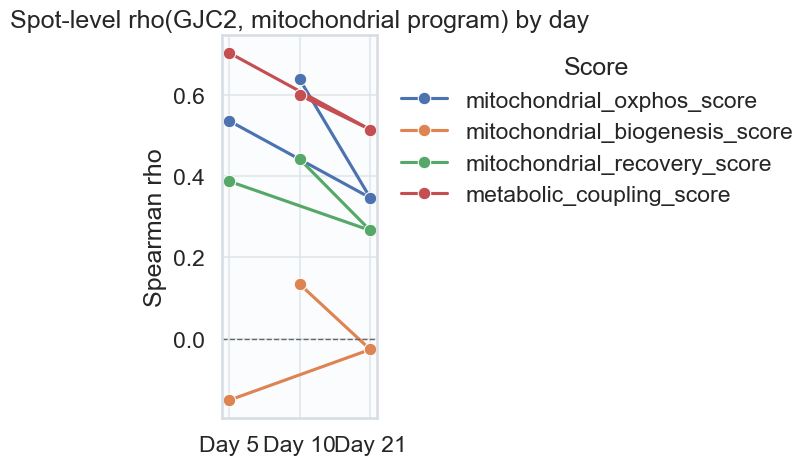

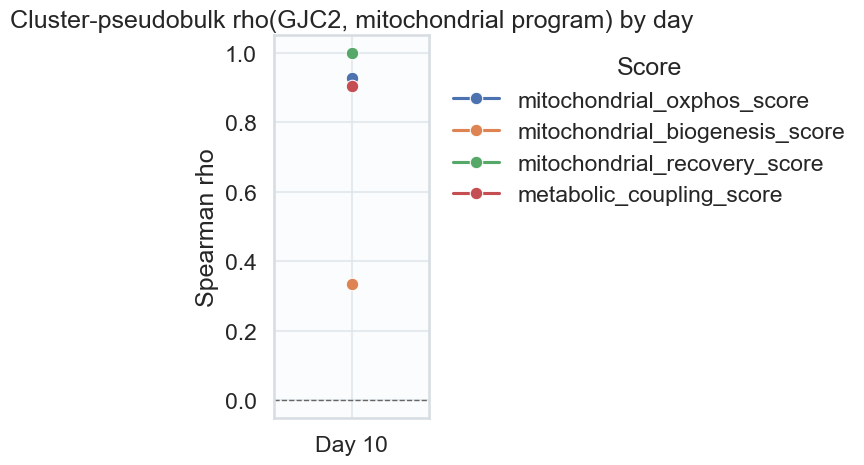

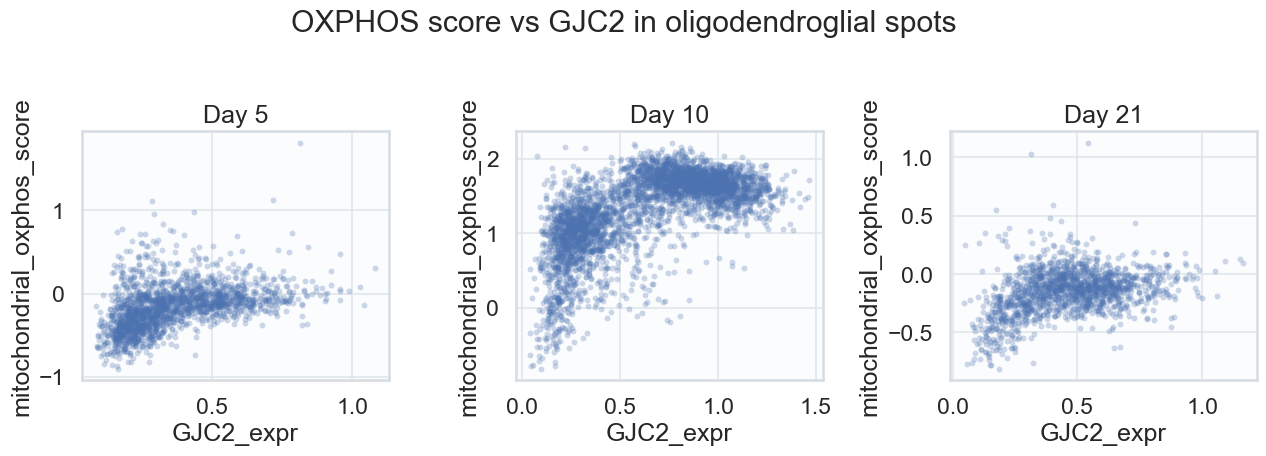

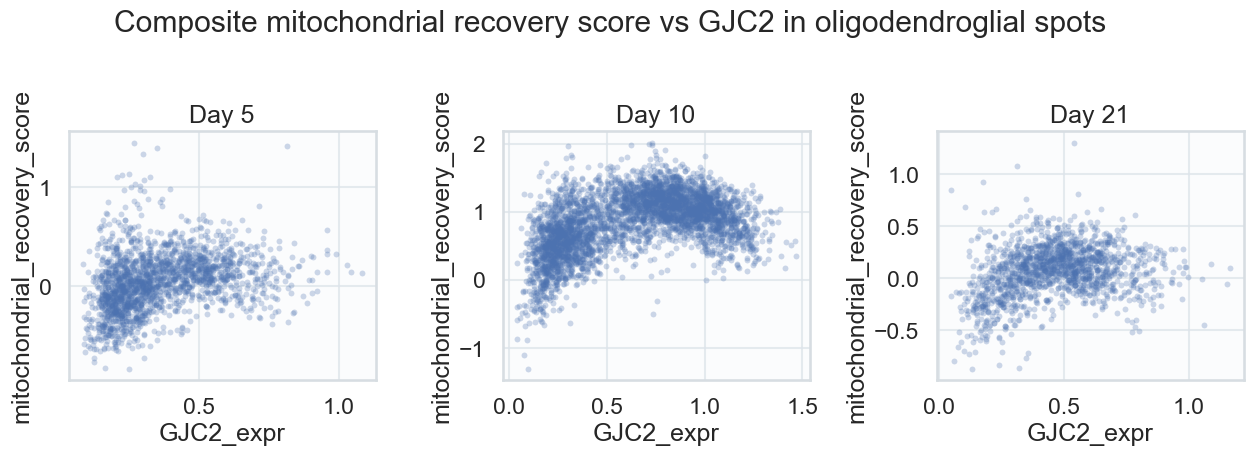

In [7]:
if not SELECTED_OLIGO_CLUSTERS:
    print("No oligodendroglial clusters are selected. Edit MANUAL_OLIGO_CLUSTERS if needed.")
else:
    q2_cols = [column for column in ["day_post_lpc", "timepoint_label", "cluster_day", "GJC2_expr", "mitochondrial_oxphos_score", "mitochondrial_biogenesis_score", "mitochondrial_recovery_score", "metabolic_coupling_score"] if column in adata_oligo.obs.columns]
    q2_frame = adata_oligo.obs[q2_cols].copy().dropna(subset=[column for column in ["GJC2_expr"] if column in q2_cols])

    score_targets = [column for column in ["mitochondrial_oxphos_score", "mitochondrial_biogenesis_score", "mitochondrial_recovery_score", "metabolic_coupling_score"] if column in q2_frame.columns]

    spot_corr_tables = []
    for score_col in score_targets:
        corr_df = spearman_by_group(q2_frame, "timepoint_label", "GJC2_expr", score_col, min_n=50)
        if not corr_df.empty:
            corr_df["score"] = score_col
            corr_df["level"] = "spot"
            spot_corr_tables.append(corr_df)
    spot_corr_table = pd.concat(spot_corr_tables, ignore_index=True) if spot_corr_tables else pd.DataFrame()

    cluster_pseudobulk = q2_frame.groupby(["timepoint_label", "cluster_day"], observed=True)[["GJC2_expr", *score_targets]].mean().reset_index()
    pseudo_corr_tables = []
    for score_col in score_targets:
        corr_df = spearman_by_group(cluster_pseudobulk, "timepoint_label", "GJC2_expr", score_col, min_n=3)
        if not corr_df.empty:
            corr_df["score"] = score_col
            corr_df["level"] = "cluster_pseudobulk"
            pseudo_corr_tables.append(corr_df)
    pseudo_corr_table = pd.concat(pseudo_corr_tables, ignore_index=True) if pseudo_corr_tables else pd.DataFrame()

    if not spot_corr_table.empty:
        display(spot_corr_table.round(3))
        save_table(spot_corr_table, RESULTS_DIR / "spot_level_correlations_by_day.csv", index=False)
        plot_correlation_trajectory(spot_corr_table, TIME_ORDER, "Spot-level rho(GJC2, mitochondrial program) by day")
        #save_current_figure(FIGURES_DIR / "spot_level_correlation_trajectory.png")

    if not pseudo_corr_table.empty:
        display(pseudo_corr_table.round(3))
        save_table(pseudo_corr_table, RESULTS_DIR / "cluster_pseudobulk_correlations_by_day.csv", index=False)
        plot_correlation_trajectory(pseudo_corr_table, TIME_ORDER, "Cluster-pseudobulk rho(GJC2, mitochondrial program) by day")
        #save_current_figure(FIGURES_DIR / "cluster_pseudobulk_correlation_trajectory.png")

        peak_table = (
            pseudo_corr_table.dropna(subset=["rho"])
            .sort_values(["score", "rho"], ascending=[True, False])
            .groupby("score", observed=True)
            .head(1)
            .reset_index(drop=True)
        )
        display(peak_table.round(3))
        save_table(peak_table, RESULTS_DIR / "peak_stage_by_score.csv", index=False)

    if "mitochondrial_oxphos_score" in q2_frame.columns:
        plot_scatter_by_day(q2_frame, "GJC2_expr", "mitochondrial_oxphos_score", "timepoint_label", TIME_ORDER, "OXPHOS score vs GJC2 in oligodendroglial spots")
        #save_current_figure(FIGURES_DIR / "scatter_oxphos_vs_gjc2_by_day.png")

    if "mitochondrial_recovery_score" in q2_frame.columns:
        plot_scatter_by_day(q2_frame, "GJC2_expr", "mitochondrial_recovery_score", "timepoint_label", TIME_ORDER, "Composite mitochondrial recovery score vs GJC2 in oligodendroglial spots")
        #save_current_figure(FIGURES_DIR / "scatter_mito_recovery_vs_gjc2_by_day.png")
